# Demo obstacle-circle analysis

This notebook keeps the raw ROS bag unchanged, removes only the initial approach from the processed output, fits the retained flange XY motion to a circle, and compares that fitted center with the synchronously recorded OptiTrack obstacle center.

{
  "recording_duration_s": 46.39995574951172,
  "approach_removed_s": 12.949987649917603,
  "circular_interval_s": [
    12.949987649917603,
    38.5499632358551
  ],
  "retained_duration_s": 25.5999755859375,
  "retained_samples": 513,
  "fitted_center_xy_m": [
    0.645855687760223,
    0.17367315674763248
  ],
  "optitrack_center_xyz_m": [
    0.6101071598324538,
    0.2173158755910301,
    0.24361578563332875
  ],
  "center_delta_fit_minus_optitrack_xy_mm": [
    35.74852792776917,
    -43.642718843397624
  ],
  "center_offset_mm": 56.41492849456026,
  "fitted_radius_mm": 97.43264846622714,
  "fitted_radial_rmse_mm": 13.57725406562645,
  "fitted_radial_p05_p95_mm": [
    74.10456174409121,
    117.41725667697813
  ],
  "distance_to_optitrack_median_mm": 106.06924100083918,
  "distance_to_optitrack_mean_mm": 105.52801800334852,
  "distance_to_optitrack_p05_p95_mm": [
    38.373200267201746,
    166.4889247071106
  ],
  "surface_clearance_median_mm": 81.06924100083917,
  "optitrack_

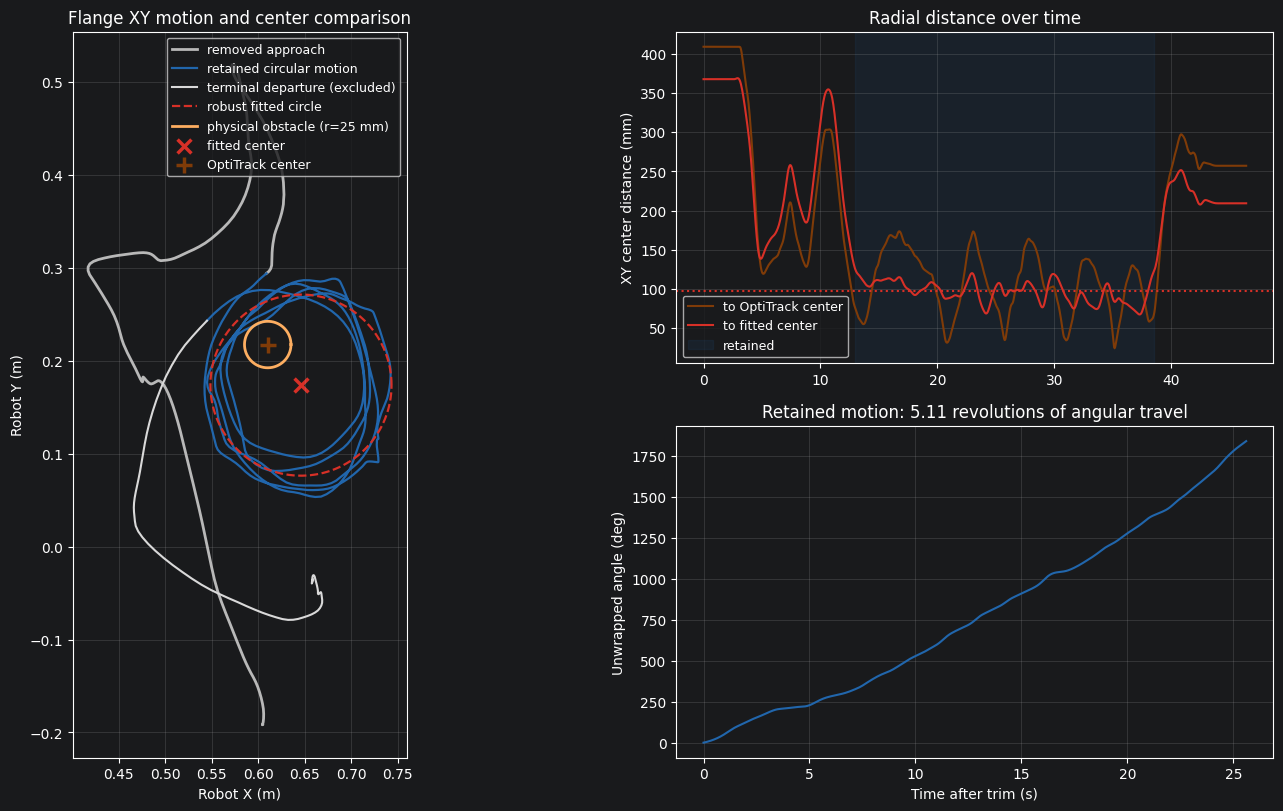

saved_npz=/home/baiyu/LearnStageConstraints/robot/stage_cons_iiwa14/data/demos/BarClean/20260827T135104_625737Z_demo_obs/processed_circle/demo_obs_circle_trimmed.npz
saved_plot=/home/baiyu/LearnStageConstraints/robot/stage_cons_iiwa14/data/demos/BarClean/20260827T135104_625737Z_demo_obs/processed_circle/demo_obs_circle_analysis.png


In [4]:
from pathlib import Path
import sys, json
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import least_squares
from scipy.signal import savgol_filter
from scipy.ndimage import binary_closing, label

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "experiments":
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from experiments.extract_bar_inspection_rosbag import (
    JOINT_TOPIC, BAR_TOPIC, OBSTACLE_TOPIC, iiwa14_fk, read_recording
)
from experiments.bar_inspect_processing import nearest_indices

SESSION_DIR = PROJECT_ROOT / "robot/stage_cons_iiwa14/data/demos/BarClean/20260827T135104_625737Z_demo_obs"
BAG_PATH = SESSION_DIR / "demo.bag"
OUTPUT_DIR = SESSION_DIR / "processed_circle"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
NPZ_PATH = OUTPUT_DIR / "demo_obs_circle_trimmed.npz"
PLOT_PATH = OUTPUT_DIR / "demo_obs_circle_analysis.png"
R_OT_TO_ROBOT = np.array([[0., 0., 1.], [1., 0., 0.], [0., 1., 0.]])
T_OT_TO_ROBOT = np.zeros(3)
OBSTACLE_RADIUS_M = 0.025
HZ = 20.0

raw_times, raw_values = read_recording(BAG_PATH, JOINT_TOPIC, BAR_TOPIC, OBSTACLE_TOPIC)
dt = 1.0 / HZ
common_start = max(v[0] for v in raw_times.values())
common_end = min(v[-1] for v in raw_times.values())
grid_abs = np.arange(np.ceil(common_start / dt) * dt, common_end, dt)
grid_s = grid_abs - grid_abs[0]
joint_idx, joint_gaps = nearest_indices(raw_times[JOINT_TOPIC], grid_abs)
obs_idx, obs_gaps = nearest_indices(raw_times[OBSTACLE_TOPIC], grid_abs)
joint_positions = raw_values[JOINT_TOPIC][joint_idx]
flange_pose = iiwa14_fk(joint_positions)
obs_pose_optitrack = raw_values[OBSTACLE_TOPIC][obs_idx]
obs_xyz_robot = (R_OT_TO_ROBOT @ obs_pose_optitrack[:, :3].T).T + T_OT_TO_ROBOT

window = min(21, len(flange_pose) // 2 * 2 - 1)
xy_smooth = np.column_stack([
    savgol_filter(flange_pose[:, axis], window_length=window, polyorder=2)
    for axis in (0, 1)
])

def algebraic_circle(xy):
    A = np.column_stack([2 * xy[:, 0], 2 * xy[:, 1], np.ones(len(xy))])
    b = np.sum(xy * xy, axis=1)
    cx, cy, c = np.linalg.lstsq(A, b, rcond=None)[0]
    return np.array([cx, cy]), np.sqrt(max(c + cx * cx + cy * cy, 0.0))

def robust_circle(xy):
    c0, r0 = algebraic_circle(xy)
    result = least_squares(
        lambda p: np.linalg.norm(xy - p[:2], axis=1) - p[2],
        np.r_[c0, r0], loss="soft_l1", f_scale=0.003,
    )
    return result.x[:2], float(result.x[2])

# Seed the fit from the middle of the recording, which contains repeated circles rather
# than either the initial approach or terminal departure.
seed = (grid_s >= 0.35 * grid_s[-1]) & (grid_s <= 0.75 * grid_s[-1])
seed_center, seed_radius = robust_circle(xy_smooth[seed])
seed_dist = np.linalg.norm(xy_smooth - seed_center, axis=1)
seed_residual = np.abs(seed_dist[seed] - seed_radius)
robust_sigma = 1.4826 * np.median(np.abs(seed_residual - np.median(seed_residual)))
radial_band_m = max(0.030, 4.0 * robust_sigma)
circle_like = np.abs(seed_dist - seed_radius) <= radial_band_m

# Bridge brief hand-motion excursions, then select the contiguous interval with the
# greatest angular travel. This rejects both approach and departure without endpoint
# assumptions.
circle_like = binary_closing(circle_like, structure=np.ones(int(round(0.6 * HZ)), dtype=bool))
labels, n_labels = label(circle_like)
best = None
for component in range(1, n_labels + 1):
    indices = np.flatnonzero(labels == component)
    if len(indices) < int(3 * HZ):
        continue
    theta = np.unwrap(np.arctan2(
        xy_smooth[indices, 1] - seed_center[1],
        xy_smooth[indices, 0] - seed_center[0],
    ))
    score = float(np.sum(np.abs(np.diff(theta))))
    if best is None or score > best[0]:
        best = (score, indices[0], indices[-1])
if best is None:
    raise RuntimeError("Could not isolate a sustained circular-motion interval.")
_, start_idx, end_idx = best
selection = slice(start_idx, end_idx + 1)

fit_center, fit_radius = robust_circle(xy_smooth[selection])
fit_dist = np.linalg.norm(xy_smooth[selection] - fit_center, axis=1)
fit_residual = fit_dist - fit_radius

obs_selected = obs_xyz_robot[selection]
obs_center = np.median(obs_selected, axis=0)
obs_center_xy = obs_center[:2]
obs_spread = np.linalg.norm(obs_selected[:, :2] - obs_center_xy, axis=1)
dist_to_optitrack = np.linalg.norm(flange_pose[selection, :2] - obs_center_xy, axis=1)
center_delta = fit_center - obs_center_xy
angles = np.unwrap(np.arctan2(
    xy_smooth[selection, 1] - fit_center[1],
    xy_smooth[selection, 0] - fit_center[0],
))
angular_travel = float(np.sum(np.abs(np.diff(angles))))
net_angular_span = float(abs(angles[-1] - angles[0]))

np.savez_compressed(
    NPZ_PATH,
    source_bag=np.asarray(str(BAG_PATH.relative_to(PROJECT_ROOT))),
    analysis_hz=np.asarray(HZ),
    timestamps_s=grid_s[selection] - grid_s[start_idx],
    source_timestamps_s=grid_s[selection],
    joint_positions=joint_positions[selection],
    flange_pose=flange_pose[selection],
    obstacle_pose_optitrack=obs_pose_optitrack[selection],
    obstacle_xyz_robot=obs_selected,
    approach_cut_index=np.asarray(start_idx),
    approach_cut_time_s=np.asarray(grid_s[start_idx]),
    circular_end_index=np.asarray(end_idx),
    circular_end_time_s=np.asarray(grid_s[end_idx]),
    fitted_circle_center_xy_m=fit_center,
    fitted_circle_radius_m=np.asarray(fit_radius),
    optitrack_obstacle_center_xyz_m=obs_center,
    fitted_minus_optitrack_center_xy_m=center_delta,
    obstacle_radius_m=np.asarray(OBSTACLE_RADIUS_M),
    optitrack_to_robot_rotation=R_OT_TO_ROBOT,
    optitrack_to_robot_translation=T_OT_TO_ROBOT,
)

summary = {
    "recording_duration_s": float(grid_s[-1]),
    "approach_removed_s": float(grid_s[start_idx]),
    "circular_interval_s": [float(grid_s[start_idx]), float(grid_s[end_idx])],
    "retained_duration_s": float(grid_s[end_idx] - grid_s[start_idx]),
    "retained_samples": int(end_idx - start_idx + 1),
    "fitted_center_xy_m": fit_center.tolist(),
    "optitrack_center_xyz_m": obs_center.tolist(),
    "center_delta_fit_minus_optitrack_xy_mm": (1000 * center_delta).tolist(),
    "center_offset_mm": 1000 * float(np.linalg.norm(center_delta)),
    "fitted_radius_mm": 1000 * fit_radius,
    "fitted_radial_rmse_mm": 1000 * float(np.sqrt(np.mean(fit_residual ** 2))),
    "fitted_radial_p05_p95_mm": (1000 * np.percentile(fit_dist, [5, 95])).tolist(),
    "distance_to_optitrack_median_mm": 1000 * float(np.median(dist_to_optitrack)),
    "distance_to_optitrack_mean_mm": 1000 * float(np.mean(dist_to_optitrack)),
    "distance_to_optitrack_p05_p95_mm": (1000 * np.percentile(dist_to_optitrack, [5, 95])).tolist(),
    "surface_clearance_median_mm": 1000 * float(np.median(dist_to_optitrack) - OBSTACLE_RADIUS_M),
    "optitrack_xy_spread_p95_mm": 1000 * float(np.percentile(obs_spread, 95)),
    "net_revolutions": net_angular_span / (2 * np.pi),
    "total_angular_travel_revolutions": angular_travel / (2 * np.pi),
    "max_joint_resampling_gap_ms": 1000 * float(np.max(joint_gaps)),
    "max_obstacle_resampling_gap_ms": 1000 * float(np.max(obs_gaps)),
}
print(json.dumps(summary, indent=2))

fig = plt.figure(figsize=(14, 8), constrained_layout=True)
gs = fig.add_gridspec(2, 2, width_ratios=[1.2, 1.0])
ax_xy = fig.add_subplot(gs[:, 0])
ax_dist = fig.add_subplot(gs[0, 1])
ax_angle = fig.add_subplot(gs[1, 1])
ax_xy.plot(flange_pose[:start_idx + 1, 0], flange_pose[:start_idx + 1, 1],
           color="0.72", lw=2, label="removed approach")
ax_xy.plot(flange_pose[selection, 0], flange_pose[selection, 1],
           color="#2166ac", lw=1.6, label="retained circular motion")
ax_xy.plot(flange_pose[end_idx:, 0], flange_pose[end_idx:, 1],
           color="0.85", lw=1.5, label="terminal departure (excluded)")
theta = np.linspace(0, 2 * np.pi, 400)
ax_xy.plot(fit_center[0] + fit_radius*np.cos(theta), fit_center[1] + fit_radius*np.sin(theta),
           "--", color="#d73027", lw=1.6, label="robust fitted circle")
ax_xy.plot(obs_center_xy[0] + OBSTACLE_RADIUS_M*np.cos(theta),
           obs_center_xy[1] + OBSTACLE_RADIUS_M*np.sin(theta),
           color="#fdae61", lw=2, label="physical obstacle (r=25 mm)")
ax_xy.scatter(*fit_center, marker="x", s=100, lw=2.5, color="#d73027", label="fitted center")
ax_xy.scatter(*obs_center_xy, marker="+", s=140, lw=2.5, color="#7f3b08", label="OptiTrack center")
ax_xy.set(aspect="equal", xlabel="Robot X (m)", ylabel="Robot Y (m)",
          title="Flange XY motion and center comparison")
ax_xy.grid(alpha=.25); ax_xy.legend(fontsize=9)

d_fit_all = np.linalg.norm(xy_smooth - fit_center, axis=1)
d_obs_all = np.linalg.norm(flange_pose[:, :2] - obs_center_xy, axis=1)
ax_dist.plot(grid_s, 1000*d_obs_all, label="to OptiTrack center", color="#7f3b08")
ax_dist.plot(grid_s, 1000*d_fit_all, label="to fitted center", color="#d73027")
ax_dist.axvspan(grid_s[start_idx], grid_s[end_idx], color="#2166ac", alpha=.10, label="retained")
ax_dist.axhline(1000*fit_radius, color="#d73027", ls=":")
ax_dist.set(ylabel="XY center distance (mm)", title="Radial distance over time")
ax_dist.grid(alpha=.25); ax_dist.legend(fontsize=9)

ax_angle.plot(grid_s[selection]-grid_s[start_idx], np.rad2deg(angles-angles[0]), color="#2166ac")
ax_angle.set(xlabel="Time after trim (s)", ylabel="Unwrapped angle (deg)",
             title=f"Retained motion: {angular_travel/(2*np.pi):.2f} revolutions of angular travel")
ax_angle.grid(alpha=.25)
fig.savefig(PLOT_PATH, dpi=180)
plt.show()
print(f"saved_npz={NPZ_PATH}")
print(f"saved_plot={PLOT_PATH}")

## Coordinate-chain audit

Verify the recorded world-frame base/object poses against the custom `pose_from_iiwa14` topic, then separate errors introduced by the relative-pose node from the still-uncalibrated Motive-base-pivot → robot-link₀ extrinsic.

In [6]:
from rosbags.highlevel import AnyReader
from scipy.spatial.transform import Rotation

BASE_WORLD_TOPIC = "/vrpn_client_node/iiwa14/pose"
OBS_WORLD_TOPIC = "/vrpn_client_node/baiyu_obs_bar/pose"
BAR_WORLD_TOPIC = "/vrpn_client_node/baiyu_bar/pose"
OBS_REL_TOPIC = "/vrpn_client_node/baiyu_obs_bar/pose_from_iiwa14"
BAR_REL_TOPIC = "/vrpn_client_node/baiyu_bar/pose_from_iiwa14"
audit_topics = (BASE_WORLD_TOPIC, OBS_WORLD_TOPIC, BAR_WORLD_TOPIC, OBS_REL_TOPIC, BAR_REL_TOPIC)
audit_t = {topic: [] for topic in audit_topics}
audit_pose = {topic: [] for topic in audit_topics}

with AnyReader([BAG_PATH]) as reader:
    connections = [c for c in reader.connections if c.topic in audit_topics]
    for connection, timestamp, raw in reader.messages(connections=connections):
        msg = reader.deserialize(raw, connection.msgtype)
        p, q = msg.pose.position, msg.pose.orientation
        audit_t[connection.topic].append(timestamp / 1e9)
        audit_pose[connection.topic].append([p.x, p.y, p.z, q.x, q.y, q.z, q.w])

for topic in audit_topics:
    audit_t[topic] = np.asarray(audit_t[topic], dtype=float)
    audit_pose[topic] = np.asarray(audit_pose[topic], dtype=float)

def reconstruct_relative(world_topic, rel_topic):
    object_t = audit_t[world_topic]
    base_indices, time_gaps = nearest_indices(audit_t[BASE_WORLD_TOPIC], object_t)
    base = audit_pose[BASE_WORLD_TOPIC][base_indices]
    obj = audit_pose[world_topic]
    R_wb = Rotation.from_quat(base[:, 3:]).as_matrix()
    p_rel = np.einsum("nij,nj->ni", np.swapaxes(R_wb, 1, 2), obj[:, :3] - base[:, :3])
    R_wo = Rotation.from_quat(obj[:, 3:]).as_matrix()
    R_rel = np.einsum("nij,njk->nik", np.swapaxes(R_wb, 1, 2), R_wo)
    q_rel = Rotation.from_matrix(R_rel).as_quat()
    reconstructed = np.column_stack([p_rel, q_rel])
    rel_indices, rel_gaps = nearest_indices(audit_t[rel_topic], object_t)
    published = audit_pose[rel_topic][rel_indices]
    pos_error = np.linalg.norm(reconstructed[:, :3] - published[:, :3], axis=1)
    rot_delta = Rotation.from_quat(reconstructed[:, 3:]).inv() * Rotation.from_quat(published[:, 3:])
    angle_error = rot_delta.magnitude()
    return {
        "reconstructed": reconstructed,
        "published": published,
        "position_error": pos_error,
        "angle_error": angle_error,
        "base_sync_gap": time_gaps,
        "rel_sync_gap": rel_gaps,
    }

obs_audit = reconstruct_relative(OBS_WORLD_TOPIC, OBS_REL_TOPIC)
bar_audit = reconstruct_relative(BAR_WORLD_TOPIC, BAR_REL_TOPIC)

def pose_spread_mm(topic):
    xyz = audit_pose[topic][:, :3]
    center = np.median(xyz, axis=0)
    return 1000 * np.percentile(np.linalg.norm(xyz - center, axis=1), [50, 95, 100])

audit_summary = {
    "topic_sample_counts": {topic: len(audit_t[topic]) for topic in audit_topics},
    "relative_node_obstacle_position_error_mm_p50_p95_max": (
        1000 * np.percentile(obs_audit["position_error"], [50, 95, 100])
    ).tolist(),
    "relative_node_bar_position_error_mm_p50_p95_max": (
        1000 * np.percentile(bar_audit["position_error"], [50, 95, 100])
    ).tolist(),
    "relative_node_obstacle_angle_error_deg_p50_p95_max": np.rad2deg(
        np.percentile(obs_audit["angle_error"], [50, 95, 100])
    ).tolist(),
    "relative_node_bar_angle_error_deg_p50_p95_max": np.rad2deg(
        np.percentile(bar_audit["angle_error"], [50, 95, 100])
    ).tolist(),
    "base_world_position_spread_mm_p50_p95_max": pose_spread_mm(BASE_WORLD_TOPIC).tolist(),
    "obstacle_world_position_spread_mm_p50_p95_max": pose_spread_mm(OBS_WORLD_TOPIC).tolist(),
    "bar_world_position_spread_mm_p50_p95_max": pose_spread_mm(BAR_WORLD_TOPIC).tolist(),
    "fixed_axis_rotation_det": float(np.linalg.det(R_OT_TO_ROBOT)),
    "current_scene_translation_m": T_OT_TO_ROBOT.tolist(),
    "translation_needed_if_circle_was_physically_centered_m": [
        float(center_delta[0]), float(center_delta[1]), None
    ],
}
print(json.dumps(audit_summary, indent=2))

{
  "topic_sample_counts": {
    "/vrpn_client_node/iiwa14/pose": 10507,
    "/vrpn_client_node/baiyu_obs_bar/pose": 11609,
    "/vrpn_client_node/baiyu_bar/pose": 9889,
    "/vrpn_client_node/baiyu_obs_bar/pose_from_iiwa14": 11080,
    "/vrpn_client_node/baiyu_bar/pose_from_iiwa14": 9517
  },
  "relative_node_obstacle_position_error_mm_p50_p95_max": [
    1.7772239894833365e-13,
    0.2016383579754175,
    16.155441956411234
  ],
  "relative_node_bar_position_error_mm_p50_p95_max": [
    1.5154773039150994e-13,
    0.07828853361885343,
    9.423373782713444
  ],
  "relative_node_obstacle_angle_error_deg_p50_p95_max": [
    1.2758385402154918e-14,
    0.05204760598548435,
    1.3001063230108472
  ],
  "relative_node_bar_angle_error_deg_p50_p95_max": [
    9.561583596282568e-15,
    0.022201774873813623,
    8.633777562500075
  ],
  "base_world_position_spread_mm_p50_p95_max": [
    0.2673999753824591,
    1.8179236594062604,
    4.258074119220282
  ],
  "obstacle_world_position_spread_

In [5]:
print(json.dumps(summary, indent=2))

{
  "recording_duration_s": 46.39995574951172,
  "approach_removed_s": 12.949987649917603,
  "circular_interval_s": [
    12.949987649917603,
    38.5499632358551
  ],
  "retained_duration_s": 25.5999755859375,
  "retained_samples": 513,
  "fitted_center_xy_m": [
    0.645855687760223,
    0.17367315674763248
  ],
  "optitrack_center_xyz_m": [
    0.6101071598324538,
    0.2173158755910301,
    0.24361578563332875
  ],
  "center_delta_fit_minus_optitrack_xy_mm": [
    35.74852792776917,
    -43.642718843397624
  ],
  "center_offset_mm": 56.41492849456026,
  "fitted_radius_mm": 97.43264846622714,
  "fitted_radial_rmse_mm": 13.57725406562645,
  "fitted_radial_p05_p95_mm": [
    74.10456174409121,
    117.41725667697813
  ],
  "distance_to_optitrack_median_mm": 106.06924100083918,
  "distance_to_optitrack_mean_mm": 105.52801800334852,
  "distance_to_optitrack_p05_p95_mm": [
    38.373200267201746,
    166.4889247071106
  ],
  "surface_clearance_median_mm": 81.06924100083917,
  "optitrack_

## Second obstacle position (`demo_obs2`)

Apply the identical segmentation and robust circle fit, then compare the two center-error vectors to test fixed-translation versus rotation-error hypotheses.

{
  "demo_obs": {
    "reported_center_xy_m": [
      0.6101071598324538,
      0.2173158755910301
    ],
    "fitted_center_xy_m": [
      0.645855687760223,
      0.17367315674763248
    ],
    "offset_fit_minus_reported_mm": [
      35.74852792776917,
      -43.642718843397624
    ],
    "offset_norm_mm": 56.41492849456026
  },
  "demo_obs2": {
    "recording_duration_s": 57.74994492530823,
    "circular_interval_s": [
      35.599966049194336,
      54.29994821548462
    ],
    "retained_duration_s": 18.699982166290283,
    "revolutions": 3.164052506537149,
    "reported_center_xy_m": [
      0.7066929765240019,
      -0.07459121859067619
    ],
    "fitted_center_xy_m": [
      0.7154264016103478,
      -0.1211290365851487
    ],
    "offset_fit_minus_reported_mm": [
      8.733425086345893,
      -46.53781799447251
    ],
    "offset_norm_mm": 47.350197649275614,
    "fitted_radius_mm": 86.60341960530955,
    "radial_rmse_mm": 13.78694859282269,
    "distance_to_reported_center_m

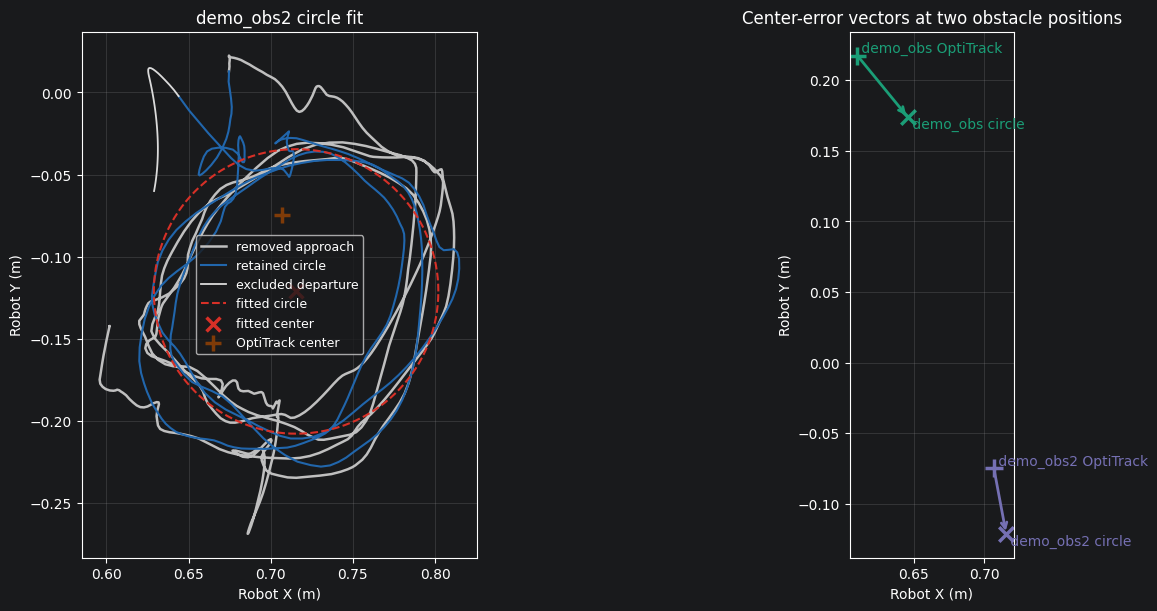

saved_npz=/home/baiyu/LearnStageConstraints/robot/stage_cons_iiwa14/data/demos/BarClean/20260827T141703_741376Z_demo_obs2/processed_circle/demo_obs2_circle_trimmed.npz
saved_plot=/home/baiyu/LearnStageConstraints/robot/stage_cons_iiwa14/data/demos/BarClean/20260827T141703_741376Z_demo_obs2/processed_circle/demo_obs2_circle_analysis.png


In [7]:
OBS2_SESSION_DIR = PROJECT_ROOT / "robot/stage_cons_iiwa14/data/demos/BarClean/20260827T141703_741376Z_demo_obs2"
OBS2_BAG_PATH = OBS2_SESSION_DIR / "demo.bag"
OBS2_OUTPUT_DIR = OBS2_SESSION_DIR / "processed_circle"
OBS2_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
OBS2_NPZ_PATH = OBS2_OUTPUT_DIR / "demo_obs2_circle_trimmed.npz"
OBS2_PLOT_PATH = OBS2_OUTPUT_DIR / "demo_obs2_circle_analysis.png"
COMPARISON_PLOT_PATH = OBS2_OUTPUT_DIR / "demo_obs_vs_demo_obs2_center_comparison.png"

def analyze_circle_bag(bag_path, hz=20.0):
    raw_t, raw_v = read_recording(bag_path, JOINT_TOPIC, BAR_TOPIC, OBSTACLE_TOPIC)
    dt = 1.0 / hz
    common_start = max(v[0] for v in raw_t.values())
    common_end = min(v[-1] for v in raw_t.values())
    t_abs = np.arange(np.ceil(common_start / dt) * dt, common_end, dt)
    t = t_abs - t_abs[0]
    j_idx, j_gap = nearest_indices(raw_t[JOINT_TOPIC], t_abs)
    o_idx, o_gap = nearest_indices(raw_t[OBSTACLE_TOPIC], t_abs)
    joints = raw_v[JOINT_TOPIC][j_idx]
    flange = iiwa14_fk(joints)
    obs_ot = raw_v[OBSTACLE_TOPIC][o_idx]
    obs_robot = (R_OT_TO_ROBOT @ obs_ot[:, :3].T).T + T_OT_TO_ROBOT
    window = min(21, len(flange) // 2 * 2 - 1)
    xy = np.column_stack([
        savgol_filter(flange[:, axis], window_length=window, polyorder=2)
        for axis in (0, 1)
    ])

    seed = (t >= 0.35 * t[-1]) & (t <= 0.75 * t[-1])
    seed_center, seed_radius = robust_circle(xy[seed])
    seed_d = np.linalg.norm(xy - seed_center, axis=1)
    seed_res = np.abs(seed_d[seed] - seed_radius)
    sigma = 1.4826 * np.median(np.abs(seed_res - np.median(seed_res)))
    band = max(0.030, 4.0 * sigma)
    circle_like = np.abs(seed_d - seed_radius) <= band
    circle_like = binary_closing(
        circle_like, structure=np.ones(int(round(0.6 * hz)), dtype=bool)
    )
    labels, n_labels = label(circle_like)
    candidates = []
    for component in range(1, n_labels + 1):
        idx = np.flatnonzero(labels == component)
        if len(idx) < int(3 * hz):
            continue
        theta = np.unwrap(np.arctan2(
            xy[idx, 1] - seed_center[1], xy[idx, 0] - seed_center[0]
        ))
        candidates.append((float(np.sum(np.abs(np.diff(theta)))), idx[0], idx[-1]))
    if not candidates:
        raise RuntimeError(f"Could not isolate circular motion in {bag_path}")
    _, start, end = max(candidates)
    sel = slice(start, end + 1)

    center, radius = robust_circle(xy[sel])
    radial = np.linalg.norm(xy[sel] - center, axis=1)
    residual = radial - radius
    obs_sel = obs_robot[sel]
    obs_center_local = np.median(obs_sel, axis=0)
    obs_spread = np.linalg.norm(obs_sel[:, :2] - obs_center_local[:2], axis=1)
    d_obs = np.linalg.norm(flange[sel, :2] - obs_center_local[:2], axis=1)
    theta = np.unwrap(np.arctan2(
        xy[sel, 1] - center[1], xy[sel, 0] - center[0]
    ))
    return {
        "t": t, "t_abs": t_abs, "joints": joints, "flange": flange,
        "obs_ot": obs_ot, "obs_robot": obs_robot, "xy": xy,
        "start": start, "end": end, "selection": sel,
        "center": center, "radius": radius, "radial": radial,
        "residual": residual, "obs_center": obs_center_local,
        "obs_spread": obs_spread, "d_obs": d_obs, "theta": theta,
        "j_gap": j_gap, "o_gap": o_gap,
    }

obs2 = analyze_circle_bag(OBS2_BAG_PATH, HZ)
s2 = obs2["selection"]
obs2_delta = obs2["center"] - obs2["obs_center"][:2]
obs1_reported = obs_center_xy.copy()
obs1_fitted = fit_center.copy()
obs1_delta = center_delta.copy()
obs2_reported = obs2["obs_center"][:2]
obs2_fitted = obs2["center"]

# With two positions, compare displacement vectors. A pure missing translation preserves
# the displacement between positions; a yaw error rotates it.
reported_move = obs2_reported - obs1_reported
fitted_move = obs2_fitted - obs1_fitted
reported_angle = np.arctan2(reported_move[1], reported_move[0])
fitted_angle = np.arctan2(fitted_move[1], fitted_move[0])
yaw_difference = np.arctan2(
    np.sin(fitted_angle - reported_angle), np.cos(fitted_angle - reported_angle)
)
move_scale = np.linalg.norm(fitted_move) / np.linalg.norm(reported_move)

comparison = {
    "demo_obs": {
        "reported_center_xy_m": obs1_reported.tolist(),
        "fitted_center_xy_m": obs1_fitted.tolist(),
        "offset_fit_minus_reported_mm": (1000 * obs1_delta).tolist(),
        "offset_norm_mm": 1000 * float(np.linalg.norm(obs1_delta)),
    },
    "demo_obs2": {
        "recording_duration_s": float(obs2["t"][-1]),
        "circular_interval_s": [
            float(obs2["t"][obs2["start"]]), float(obs2["t"][obs2["end"]])
        ],
        "retained_duration_s": float(obs2["t"][obs2["end"]] - obs2["t"][obs2["start"]]),
        "revolutions": float(np.sum(np.abs(np.diff(obs2["theta"]))) / (2*np.pi)),
        "reported_center_xy_m": obs2_reported.tolist(),
        "fitted_center_xy_m": obs2_fitted.tolist(),
        "offset_fit_minus_reported_mm": (1000 * obs2_delta).tolist(),
        "offset_norm_mm": 1000 * float(np.linalg.norm(obs2_delta)),
        "fitted_radius_mm": 1000 * float(obs2["radius"]),
        "radial_rmse_mm": 1000 * float(np.sqrt(np.mean(obs2["residual"]**2))),
        "distance_to_reported_center_median_mm": 1000 * float(np.median(obs2["d_obs"])),
        "distance_to_reported_center_p05_p95_mm": (
            1000 * np.percentile(obs2["d_obs"], [5, 95])
        ).tolist(),
        "optitrack_xy_spread_p95_mm": 1000 * float(np.percentile(obs2["obs_spread"], 95)),
    },
    "cross_position_test": {
        "offset_vector_change_mm": (1000 * (obs2_delta - obs1_delta)).tolist(),
        "offset_vector_change_norm_mm": 1000 * float(np.linalg.norm(obs2_delta - obs1_delta)),
        "reported_obstacle_move_mm": (1000 * reported_move).tolist(),
        "fitted_circle_center_move_mm": (1000 * fitted_move).tolist(),
        "move_length_ratio_fitted_over_reported": float(move_scale),
        "direction_difference_deg": float(np.rad2deg(yaw_difference)),
    },
}
print(json.dumps(comparison, indent=2))

np.savez_compressed(
    OBS2_NPZ_PATH,
    source_bag=np.asarray(str(OBS2_BAG_PATH.relative_to(PROJECT_ROOT))),
    analysis_hz=np.asarray(HZ),
    timestamps_s=obs2["t"][s2] - obs2["t"][obs2["start"]],
    source_timestamps_s=obs2["t"][s2],
    joint_positions=obs2["joints"][s2],
    flange_pose=obs2["flange"][s2],
    obstacle_pose_optitrack=obs2["obs_ot"][s2],
    obstacle_xyz_robot=obs2["obs_robot"][s2],
    approach_cut_time_s=np.asarray(obs2["t"][obs2["start"]]),
    circular_end_time_s=np.asarray(obs2["t"][obs2["end"]]),
    fitted_circle_center_xy_m=obs2_fitted,
    fitted_circle_radius_m=np.asarray(obs2["radius"]),
    optitrack_obstacle_center_xyz_m=obs2["obs_center"],
    fitted_minus_optitrack_center_xy_m=obs2_delta,
)

fig, axes = plt.subplots(1, 2, figsize=(13, 6), constrained_layout=True)
ax = axes[0]
ax.plot(obs2["flange"][:obs2["start"]+1, 0], obs2["flange"][:obs2["start"]+1, 1],
        color="0.75", lw=1.8, label="removed approach")
ax.plot(obs2["flange"][s2, 0], obs2["flange"][s2, 1],
        color="#2166ac", lw=1.5, label="retained circle")
ax.plot(obs2["flange"][obs2["end"]:, 0], obs2["flange"][obs2["end"]:, 1],
        color="0.86", lw=1.3, label="excluded departure")
theta_plot = np.linspace(0, 2*np.pi, 400)
ax.plot(obs2_fitted[0] + obs2["radius"]*np.cos(theta_plot),
        obs2_fitted[1] + obs2["radius"]*np.sin(theta_plot),
        "--", color="#d73027", label="fitted circle")
ax.scatter(*obs2_fitted, marker="x", s=100, lw=2.5, color="#d73027", label="fitted center")
ax.scatter(*obs2_reported, marker="+", s=140, lw=2.5, color="#7f3b08", label="OptiTrack center")
ax.set(aspect="equal", xlabel="Robot X (m)", ylabel="Robot Y (m)",
       title="demo_obs2 circle fit")
ax.grid(alpha=.25); ax.legend(fontsize=9)

ax = axes[1]
for reported, fitted, name, color in [
    (obs1_reported, obs1_fitted, "demo_obs", "#1b9e77"),
    (obs2_reported, obs2_fitted, "demo_obs2", "#7570b3"),
]:
    ax.scatter(*reported, marker="+", s=150, lw=2.5, color=color)
    ax.scatter(*fitted, marker="x", s=110, lw=2.5, color=color)
    ax.annotate("", xy=fitted, xytext=reported,
                arrowprops=dict(arrowstyle="->", color=color, lw=2))
    ax.text(reported[0], reported[1], f" {name} OptiTrack", color=color, va="bottom")
    ax.text(fitted[0], fitted[1], f" {name} circle", color=color, va="top")
ax.set(aspect="equal", xlabel="Robot X (m)", ylabel="Robot Y (m)",
       title="Center-error vectors at two obstacle positions")
ax.grid(alpha=.25)
fig.savefig(OBS2_PLOT_PATH, dpi=180)
fig.savefig(COMPARISON_PLOT_PATH, dpi=180)
plt.show()
print(f"saved_npz={OBS2_NPZ_PATH}")
print(f"saved_plot={OBS2_PLOT_PATH}")

In [9]:
for lo, hi in [(3.5,54.5),(8,54.5),(12,54.5),(18,54.5),(24,54.5),(35.6,54.3)]:
    mask = (obs2["t"] >= lo) & (obs2["t"] <= hi)
    c, radius = robust_circle(obs2["xy"][mask])
    dist = np.linalg.norm(obs2["xy"][mask] - c, axis=1)
    print(f"{lo:4.1f}-{hi:4.1f}s center={c} r={1000*radius:6.1f}mm rmse={1000*np.sqrt(np.mean((dist-radius)**2)):5.1f}mm offset={1000*(c-obs2_reported)}")

 3.5-54.5s center=[ 0.71679382 -0.11932537] r=  88.6mm rmse= 18.9mm offset=[ 10.1008443  -44.73414905]
 8.0-54.5s center=[ 0.71747775 -0.11817907] r=  87.4mm rmse= 18.5mm offset=[ 10.78477579 -43.58784688]
12.0-54.5s center=[ 0.71592639 -0.11803904] r=  86.9mm rmse= 18.8mm offset=[  9.23341109 -43.44782197]
18.0-54.5s center=[ 0.715562   -0.11811792] r=  87.0mm rmse= 17.7mm offset=[  8.86902816 -43.52669887]
24.0-54.5s center=[ 0.7145734  -0.11600544] r=  86.9mm rmse= 18.0mm offset=[  7.88042506 -41.41421653]
35.6-54.3s center=[ 0.7154634  -0.12119776] r=  86.6mm rmse= 13.5mm offset=[  8.7704277  -46.60654618]


In [10]:
R2 = np.array([
    [np.cos(yaw_difference), -np.sin(yaw_difference)],
    [np.sin(yaw_difference),  np.cos(yaw_difference)],
])
reported_centers = np.vstack([obs1_reported, obs2_reported])
fitted_centers = np.vstack([obs1_fitted, obs2_fitted])
translation_2d = np.mean(fitted_centers - (R2 @ reported_centers.T).T, axis=0)
predicted = (R2 @ reported_centers.T).T + translation_2d
residual_mm = 1000 * np.linalg.norm(predicted - fitted_centers, axis=1)
two_point_extrinsic = {
    "additional_yaw_correction_deg": float(np.rad2deg(yaw_difference)),
    "translation_after_yaw_correction_mm": (1000 * translation_2d).tolist(),
    "two_point_fit_residual_mm": residual_mm.tolist(),
}
print(json.dumps(two_point_extrinsic, indent=2))

{
  "additional_yaw_correction_deg": -5.029918591092448,
  "translation_after_yaw_correction_mm": [
    18.519683352461456,
    12.910377072343174
  ],
  "two_point_fit_residual_mm": [
    2.2856205374793976,
    2.2856205374793843
  ]
}
